# Week 4 — Urdu OCR: TrOCR Fine-Tuning

## Step 1 — Install dependencies

In [9]:
!pip install -q sentencepiece
print('Dependencies installed')

Dependencies installed


## Step 2 — Load TrOCR model

In [10]:
from transformers import ViTImageProcessor, RobertaTokenizer, VisionEncoderDecoderModel, TrOCRProcessor
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cpu':
    print('WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU')

image_processor = ViTImageProcessor.from_pretrained('microsoft/trocr-base-printed')
tokenizer = RobertaTokenizer.from_pretrained('microsoft/trocr-base-printed')
processor = TrOCRProcessor(image_processor=image_processor, tokenizer=tokenizer)

model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed')
model = model.to(device)
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size

print('Model loaded successfully!')
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

Using device: cuda


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully!
Model parameters: 333,921,792


## Step 3 — Build train/test datasets

In [11]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image

df = pd.read_csv('labels.csv')
train_df, test_df = train_test_split(df, test_size=0.15, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

class UrduOCRDataset(Dataset):
    def __init__(self, df, processor, image_root='.', max_target_length=64):
        self.df = df
        self.processor = processor
        self.image_root = image_root
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.image_root, row['image'])
        image = Image.open(image_path).convert('RGB')
        pixel_values = self.processor(image, return_tensors='pt').pixel_values.squeeze()
        labels = self.processor.tokenizer(
            row['text'], padding='max_length', max_length=self.max_target_length, truncation=True
        ).input_ids
        labels = [l if l != self.processor.tokenizer.pad_token_id else -100 for l in labels]
        return {'pixel_values': pixel_values, 'labels': torch.tensor(labels)}

train_dataset = UrduOCRDataset(train_df, processor)
test_dataset = UrduOCRDataset(test_df, processor)

print(f'train_dataset: {len(train_dataset)} | test_dataset: {len(test_dataset)}')

train_dataset: 425 | test_dataset: 75


## Step 0 check — sanity gate 

In [12]:
try:
    train_dataset
    test_dataset
    print(f'PASS - train_dataset size: {len(train_dataset)}')
    print(f'PASS - test_dataset size: {len(test_dataset)}')
except NameError:
    raise RuntimeError('train_dataset / test_dataset not found.')

PASS - train_dataset size: 425
PASS - test_dataset size: 75


## Step 4 — Training setup

In [13]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4)

optimizer = AdamW(model.parameters(), lr=5e-5)

print(f'Training batches per epoch: {len(train_loader)}')
print('Ready to train!')

Training batches per epoch: 107
Ready to train!


In [14]:
num_epochs = 30
loss_history = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    print(f'\nEpoch {epoch + 1}/{num_epochs}')
    print('-' * 30)

    for batch_idx, batch in enumerate(train_loader):
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        if batch_idx % 10 == 0:
            print(f'  Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}')

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f'Epoch {epoch + 1} complete | Average Loss: {avg_loss:.4f}')

print('\nTraining complete!')
print(f'Loss went from {loss_history[0]:.4f} to {loss_history[-1]:.4f}')


Epoch 1/30
------------------------------
  Batch 0/107 | Loss: 17.4423
  Batch 10/107 | Loss: 4.8685
  Batch 20/107 | Loss: 3.9108
  Batch 30/107 | Loss: 3.6141
  Batch 40/107 | Loss: 3.4070
  Batch 50/107 | Loss: 3.2603
  Batch 60/107 | Loss: 3.2095
  Batch 70/107 | Loss: 3.1449
  Batch 80/107 | Loss: 3.1515
  Batch 90/107 | Loss: 3.3006
  Batch 100/107 | Loss: 3.4455
Epoch 1 complete | Average Loss: 3.8780

Epoch 2/30
------------------------------
  Batch 0/107 | Loss: 3.0549
  Batch 10/107 | Loss: 3.3276
  Batch 20/107 | Loss: 3.2491
  Batch 30/107 | Loss: 3.2153
  Batch 40/107 | Loss: 3.1498
  Batch 50/107 | Loss: 3.0818
  Batch 60/107 | Loss: 3.1582
  Batch 70/107 | Loss: 3.2395
  Batch 80/107 | Loss: 3.0928
  Batch 90/107 | Loss: 3.0567
  Batch 100/107 | Loss: 3.0458
Epoch 2 complete | Average Loss: 3.0554

Epoch 3/30
------------------------------
  Batch 0/107 | Loss: 2.7534
  Batch 10/107 | Loss: 2.8781
  Batch 20/107 | Loss: 3.0263
  Batch 30/107 | Loss: 2.8774
  Batch 40/

## Step 5 — Evaluate

In [15]:
model.eval()
print('=== Model Evaluation on Test Images ===\n')

correct = 0
total = 0
wrong_examples = []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].clone()
        labels[labels == -100] = processor.tokenizer.pad_token_id

        generated_ids = model.generate(
            pixel_values,
            max_new_tokens=64,
            repetition_penalty=2.0,
            no_repeat_ngram_size=2
        )
        generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)
        actual_text = processor.batch_decode(labels, skip_special_tokens=True)

        for pred, actual in zip(generated_text, actual_text):
            total += 1
            if pred.strip() == actual.strip():
                correct += 1
            else:
                wrong_examples.append((pred, actual))
            print(f'Predicted: {pred}')
            print(f'Actual:    {actual}\n')

=== Model Evaluation on Test Images ===

Predicted: بازار میں نئے کپ ؑنو�ستدجض؁ہ ۓۤ�Tڮل
Actual:    بازار میں نئے کپڑے آئے ہیں

Predicted: ی کتاب ؾن م ٯلبنسرعسمداالوع و٭ ہ�
Actual:    یہ کتاب بہت دلچسپ ہے

Predicted: اس نے اپند تلب مکمتوعش گر�ی
Actual:    اس نے اپنی تعلیم مکمل کی

Predicted: وہ ڈاٹر بند م؆ پتاؑلامی ۯے
Actual:    وہ ڈاکٹر بننا چاہتا ہے

Predicted: کرای دۭ ساطلب مشالتہن ے
Actual:    کراچی ایک ساحلی شہر ہے

Predicted: اس نے مشکل وقتان غ ہردوعیمنسن گۓ
Actual:    اس نے مشکل وقت میں میری مدد کی

Predicted: موب ئل ٢ج کاضت ماریدال و٨نسعورت دن �ے
Actual:    موبائل فون آج کل ضرورت بن گیا ہے

Predicted: ہم نے ؾاڑوب کراس مدشینت لس�.
Actual:    ہم نے پہاڑوں کی سیر کی

Predicted: میرد ؁ناڨس�تو کلاتن ٱدہے ۈۺ
Actual:    میری والدہ کھانا بنا رہی ہیں

Predicted: وہ اھمح ؆نق ٳلتسداعا ےۯی
Actual:    وہ ہمیشہ سچ بولتا ہے

Predicted: ی اکے مثالب شاعلتد �و
Actual:    یہ ایک مثال ہے

Predicted: وہ صبحڬلدان مٹتس ٱاتا ےۯی
Actual:    وہ صبح جلدی اٹھتا ہے

Predicted: ہم نؒران ؾی گاتتوٲبلدس ماة ۈۺ


## Step 6 — Training loss

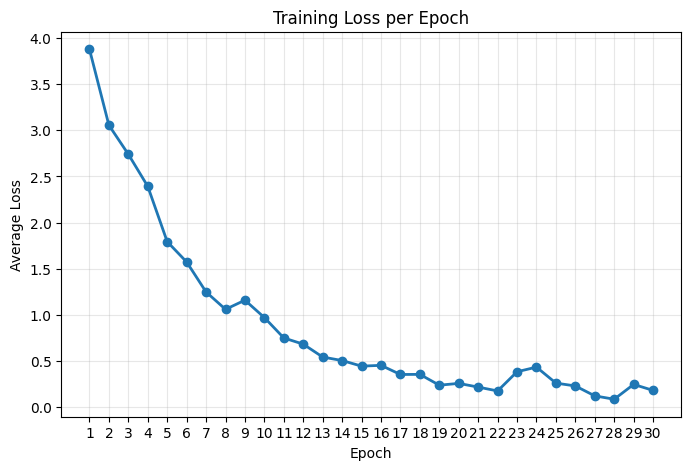

In [18]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(loss_history) + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_history, marker='o', linewidth=2)
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.xticks(epochs)
plt.grid(True, alpha=0.3)
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Save model to Drive

In [19]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    save_path = '/content/drive/MyDrive/SI26-urdu-ocr-model'
except ImportError:
    save_path = './SI26-urdu-ocr-model'

model.save_pretrained(save_path)
processor.save_pretrained(save_path)
print(f'Model saved to: {save_path}')

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/SI26-urdu-ocr-model
